# Store Sales Forecasting — Time Series Analysis & Prediction

**Competition:** Predict sales for thousands of product families at Favorita stores in Ecuador.

**Metric:** RMSLE (Root Mean Squared Logarithmic Error)

**Dataset Files:**
| File | What it contains |
|------|-----------------|
| `train.csv` | Sales history: store, product family, promotions, sales (2013–2017) |
| `test.csv` | 15 days to predict (right after training period ends) |
| `stores.csv` | Store info: city, state, type (A–E), cluster |
| `oil.csv` | Daily oil prices — Ecuador's economy depends heavily on oil exports |
| `holidays_events.csv` | Holidays with transfer/bridge logic |
| `transactions.csv` | Daily transaction counts per store |

**Ecuador-Specific Domain Knowledge:**
- Public sector wages paid on **15th** and **last day of month** → sales spikes
- **April 16, 2016**: Magnitude 7.8 earthquake → relief donations affected grocery sales for weeks
- Holidays can be **transferred** to a different date by the government
- *Bridge* days extend holidays; *Work Days* compensate for them

**Our Pipeline:**
Data Loading → EDA → Feature Engineering (30+ features) → Baseline (Random Forest) → LightGBM & XGBoost at 7/15/30-day intervals → Recursive submission

In [16]:
!pip install numpy pandas matplotlib seaborn scikit-learn lightgbm xgboost --quiet
print("Libraries installed.")

Libraries installed.


In [17]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb, gc, warnings
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, np.clip(y_pred, 0, None)))

## **Data Loading


In [18]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/favoriteabhi/store-sales/"

train = pd.read_csv(DATA_PATH + "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_PATH + "test.csv", parse_dates=["date"])
stores = pd.read_csv(DATA_PATH + "stores.csv")
oil = pd.read_csv(DATA_PATH + "oil.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_PATH + "holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv(DATA_PATH + "transactions.csv", parse_dates=["date"])
sample_sub = pd.read_csv(DATA_PATH + "sample_submission.csv")

print("Train:", train.shape)
print("Test:", test.shape)
print("Stores:", stores.shape)
print("Oil:", oil.shape)
print("Holidays:", holidays.shape)
print("Transactions:", transactions.shape)
# train = pd.read_csv('train.csv', parse_dates=['date'])
# test  = pd.read_csv('test.csv',  parse_dates=['date'])
# stores = pd.read_csv('stores.csv')
# oil    = pd.read_csv('oil.csv', parse_dates=['date'])
# holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])
# transactions = pd.read_csv('transactions.csv', parse_dates=['date'])
# sample_sub = pd.read_csv('sample_submission.csv')

# print(f"Train: {train.shape[0]:,} rows | {train['date'].min().date()} to {train['date'].max().date()}")
# print(f"Test:  {test.shape[0]:,} rows  | {test['date'].min().date()} to {test['date'].max().date()}")
# print(f"Stores: {stores.shape[0]} | Oil: {oil.shape[0]} | Holidays: {holidays.shape[0]} | Transactions: {transactions.shape[0]:,}")

Train: (3000888, 6)
Test: (28512, 5)
Stores: (54, 5)
Oil: (1218, 2)
Holidays: (350, 6)
Transactions: (83488, 3)


## Data Inspection

**What to check:** data types, missing values, unique categories, value ranges, and anomalies.

In [19]:
print("--- Train ---")
print(f"Columns: {list(train.columns)}")
print(f"Missing: {train.isnull().sum().to_dict()}")
print(f"Unique stores: {train['store_nbr'].nunique()} | Unique families: {train['family'].nunique()}")
print(f"Zero sales: {(train['sales']==0).sum():,} ({(train['sales']==0).mean()*100:.1f}%)")
print(f"Negative sales: {(train['sales']<0).sum()}")
print(f"\nProduct families: {sorted(train['family'].unique())}")
train.head()

--- Train ---
Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']
Missing: {'id': 0, 'date': 0, 'store_nbr': 0, 'family': 0, 'sales': 0, 'onpromotion': 0}
Unique stores: 54 | Unique families: 33
Zero sales: 939,130 (31.3%)
Negative sales: 0

Product families: ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [20]:
print("--- Stores ---")
print(f"Types: {stores['type'].value_counts().to_dict()}")
print(f"Cities: {stores['city'].nunique()} | States: {stores['state'].nunique()}")
stores

--- Stores ---
Types: {'D': 18, 'C': 15, 'A': 9, 'B': 8, 'E': 4}
Cities: 22 | States: 16


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [21]:
print("--- Oil ---")
oil.rename(columns={'dcoilwtico': 'oil_price'}, inplace=True)
print(f"Missing: {oil['oil_price'].isnull().sum()}/{len(oil)}")
oil['oil_price'] = oil['oil_price'].interpolate().bfill()
print(f"After interpolation: {oil['oil_price'].isnull().sum()} missing")

--- Oil ---
Missing: 43/1218
After interpolation: 0 missing


In [22]:
print("--- Holidays ---")
print(f"Types: {holidays['type'].value_counts().to_dict()}")
print(f"Locales: {holidays['locale'].value_counts().to_dict()}")
print(f"Transferred: {holidays['transferred'].sum()} entries")
holidays.head()

--- Holidays ---
Types: {'Holiday': 221, 'Event': 56, 'Additional': 51, 'Transfer': 12, 'Bridge': 5, 'Work Day': 5}
Locales: {'National': 174, 'Local': 152, 'Regional': 24}
Transferred: 12 entries


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [23]:
print("--- Transactions ---")
print(f"Range: {transactions['date'].min().date()} to {transactions['date'].max().date()}")
print(f"Stores: {transactions['store_nbr'].nunique()}")
transactions.describe()

--- Transactions ---
Range: 2013-01-01 to 2017-08-15
Stores: 54


,date,store_nbr,transactions
count,83488,83488.000000,83488.000000
mean,2015-05-20 16:07:40.866232064,26.939237,1694.602158
min,2013-01-01 00:00:00,1.000000,5.000000
25%,2014-03-27 00:00:00,13.000000,1046.000000
50%,2015-06-08 00:00:00,27.000000,1393.000000
75%,2016-07-14 06:00:00,40.000000,2079.000000
max,2017-08-15 00:00:00,54.000000,8359.000000
std,NaN,15.608204,963.286644


## Exploratory Data Analysis

**Why EDA?** Understanding patterns in the data tells us what features to build.
We analyze: overall trend, earthquake impact, weekly/monthly cycles, payday effect,
oil correlation, product families, store types, promotions, and year-over-year growth.

### Overall Sales Trend

**What:** Total daily sales across all stores over the entire training period.
**Why:** To see the big picture — trend direction, seasonal cycles, anomalies.

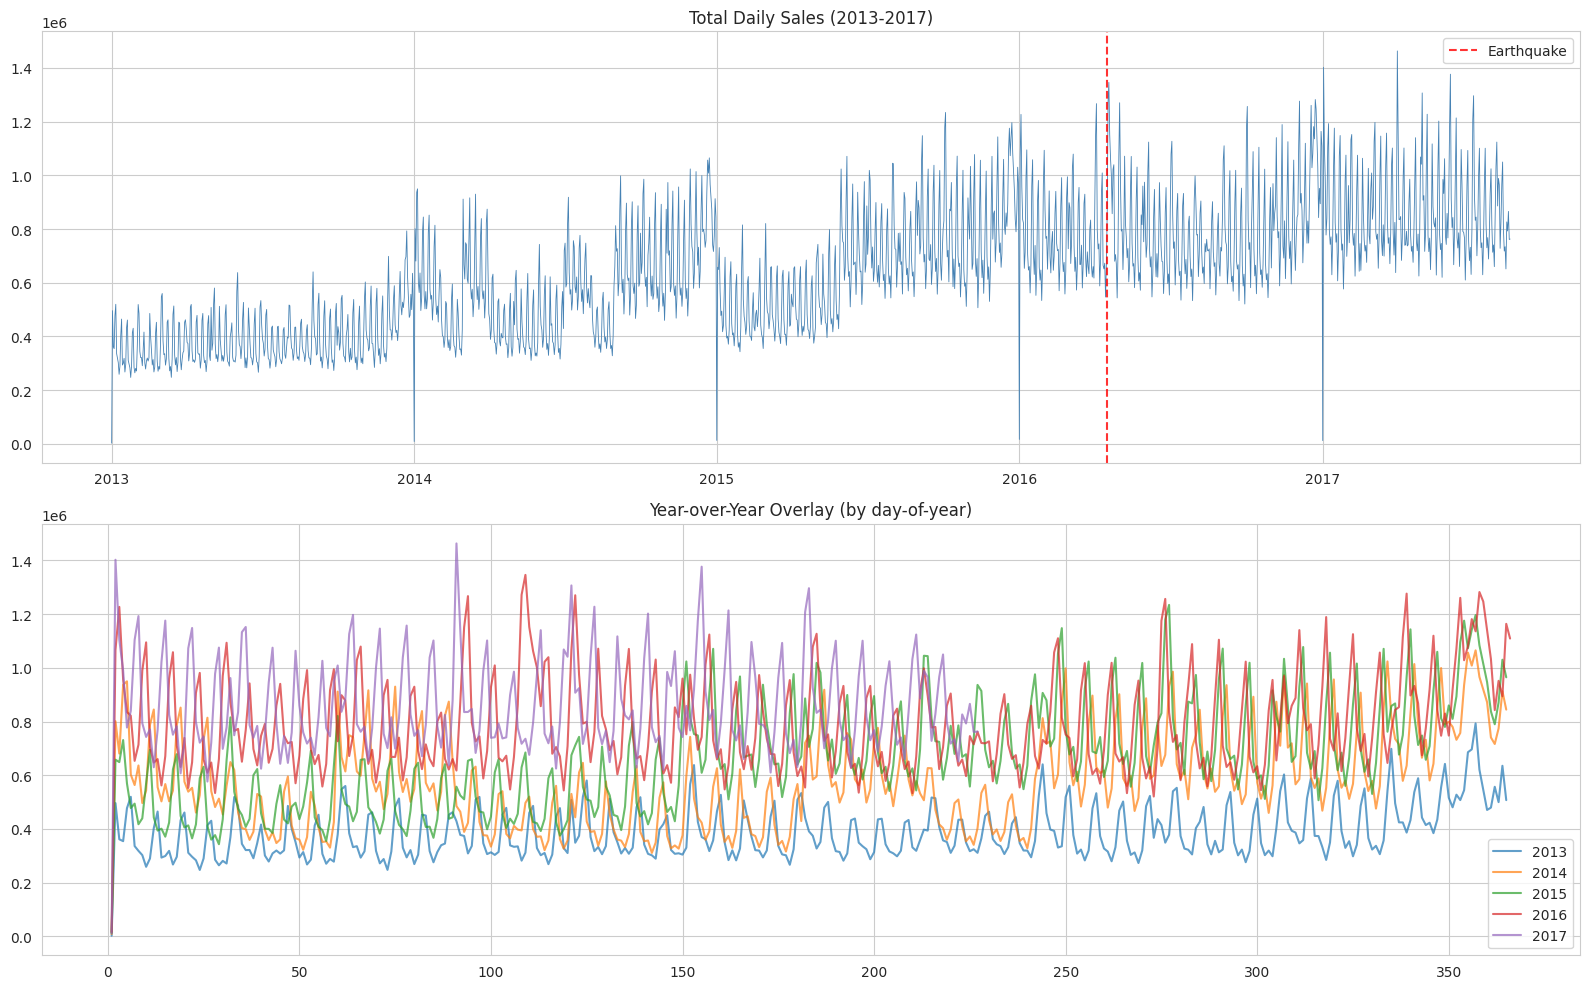

Findings:
  - Clear upward trend over the years
  - Strong December spikes every year (Christmas)
  - Earthquake disruption visible in mid-2016


In [24]:
daily_sales = train.groupby('date')['sales'].sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(daily_sales.index, daily_sales.values, linewidth=0.6, color='steelblue')
axes[0].axvline(pd.Timestamp('2016-04-16'), color='red', ls='--', alpha=0.8, label='Earthquake')
axes[0].set_title('Total Daily Sales (2013-2017)')
axes[0].legend()

for yr in range(2013, 2018):
    m = daily_sales.index.year == yr
    axes[1].plot(daily_sales[m].index.dayofyear, daily_sales[m].values, label=str(yr), alpha=0.7)
axes[1].set_title('Year-over-Year Overlay (by day-of-year)')
axes[1].legend()
plt.tight_layout(); plt.show()

print("Findings:")
print("  - Clear upward trend over the years")
print("  - Strong December spikes every year (Christmas)")
print("  - Earthquake disruption visible in mid-2016")

### Earthquake Impact (April 16, 2016)

**What:** Zoom into the earthquake period to measure the sales impact.
**Why:** We may need a special feature flag for this period since normal patterns break.

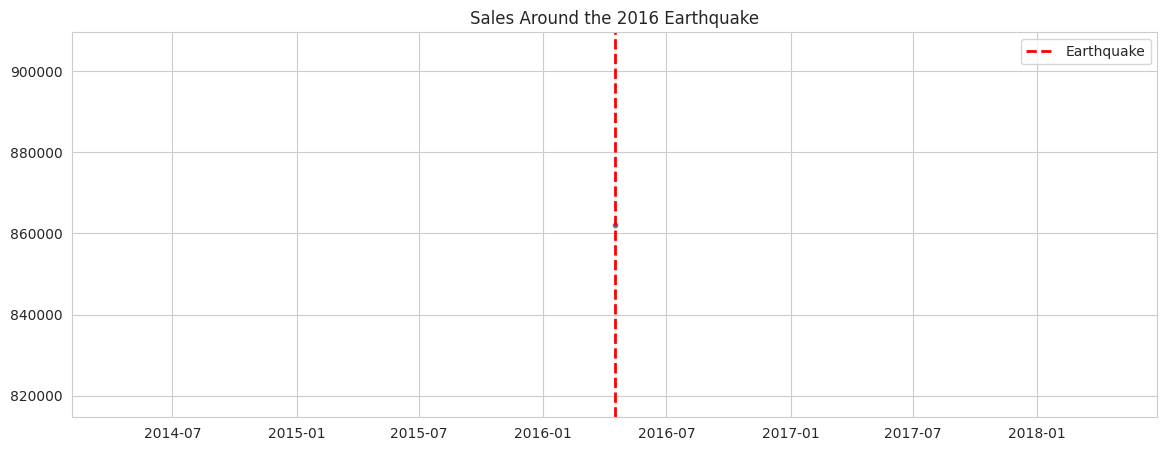

   7-day: Before=nan | After=nan | Change=+nan%
  14-day: Before=nan | After=nan | Change=+nan%
  30-day: Before=nan | After=nan | Change=+nan%


In [25]:
eq = pd.Timestamp('2016-04-16')
window = daily_sales[(daily_sales.index >= eq - pd.Timedelta(30)) & (daily_sales.index <= eq + pd.Timedelta(60))]

plt.figure(figsize=(14, 5))
plt.plot(window.index, window.values, 'o-', ms=3, color='steelblue')
plt.axvline(eq, color='red', ls='--', lw=2, label='Earthquake')
plt.axvspan(eq, eq + pd.Timedelta(14), alpha=0.1, color='red')
plt.title('Sales Around the 2016 Earthquake'); plt.legend(); plt.show()

for d in [7, 14, 30]:
    pre = daily_sales[(daily_sales.index >= eq-pd.Timedelta(d)) & (daily_sales.index < eq)].mean()
    post = daily_sales[(daily_sales.index > eq) & (daily_sales.index <= eq+pd.Timedelta(d))].mean()
    print(f"  {d:2d}-day: Before={pre:,.0f} | After={post:,.0f} | Change={((post/pre)-1)*100:+.1f}%")

### Weekly & Monthly Seasonality

**What:** Average sales by day-of-week and month.
**Why:** Weekly and monthly cycles are among the strongest patterns in retail sales.

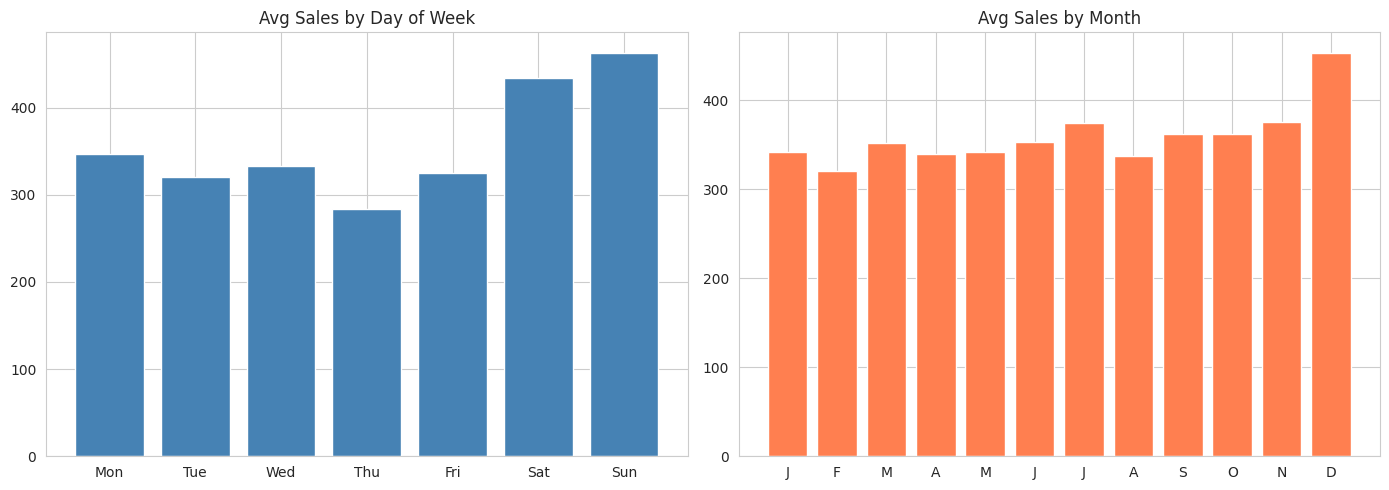

Peak day: Sun (463)
Peak month: Month 12 (454)


In [26]:
train['dayofweek'] = train['date'].dt.dayofweek
train['month'] = train['date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow = train.groupby('dayofweek')['sales'].mean()
axes[0].bar(range(7), dow.values, color='steelblue')
axes[0].set_xticks(range(7)); axes[0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[0].set_title('Avg Sales by Day of Week')

mo = train.groupby('month')['sales'].mean()
axes[1].bar(range(1,13), mo.values, color='coral')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].set_title('Avg Sales by Month')
plt.tight_layout(); plt.show()

print(f"Peak day: {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][dow.idxmax()]} ({dow.max():.0f})")
print(f"Peak month: Month {mo.idxmax()} ({mo.max():.0f})")

### Payday Effect

**What:** Sales around the 15th and last day of month (public sector payday in Ecuador).
**Why:** If there's a spike, we should add payday-related features.

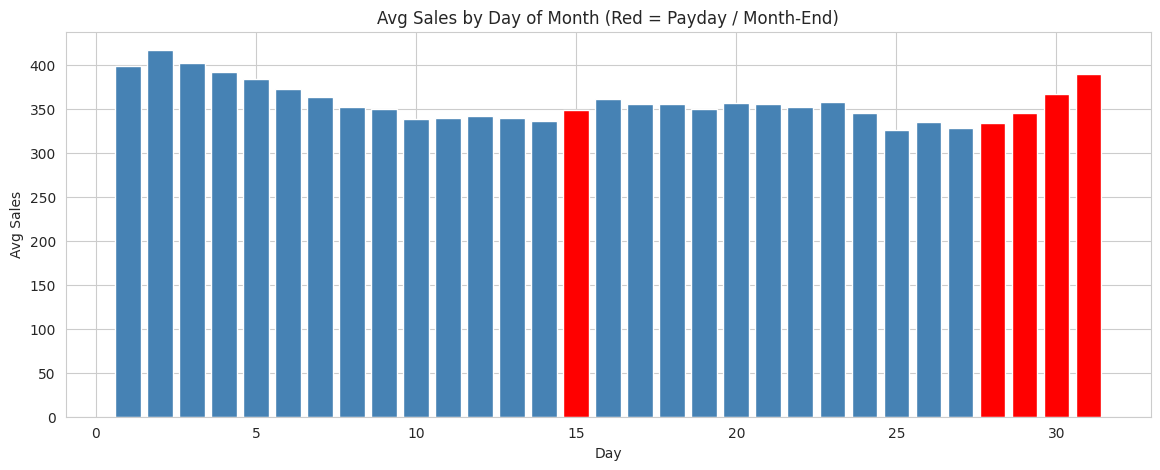

Regular days: 357.4 | Payday days: 362.5 | Lift: 1.4%


In [27]:
train['day'] = train['date'].dt.day
day_avg = train.groupby('day')['sales'].mean()

colors = ['red' if d in [15, 28, 29, 30, 31] else 'steelblue' for d in range(1, 32)]
plt.bar(range(1, 32), day_avg.values, color=colors)
plt.title('Avg Sales by Day of Month (Red = Payday / Month-End)')
plt.xlabel('Day'); plt.ylabel('Avg Sales'); plt.show()

train['is_month_end'] = train['date'].dt.is_month_end.astype(int)
pay = train.groupby((train['day']==15) | (train['is_month_end']==1))['sales'].mean()
print(f"Regular days: {pay[False]:,.1f} | Payday days: {pay[True]:,.1f} | Lift: {(pay[True]/pay[False]-1)*100:.1f}%")

### Oil Price Correlation

**What:** Overlay oil prices with total sales.
**Why:** Ecuador's economy is oil-dependent — oil price drops may reduce consumer spending.

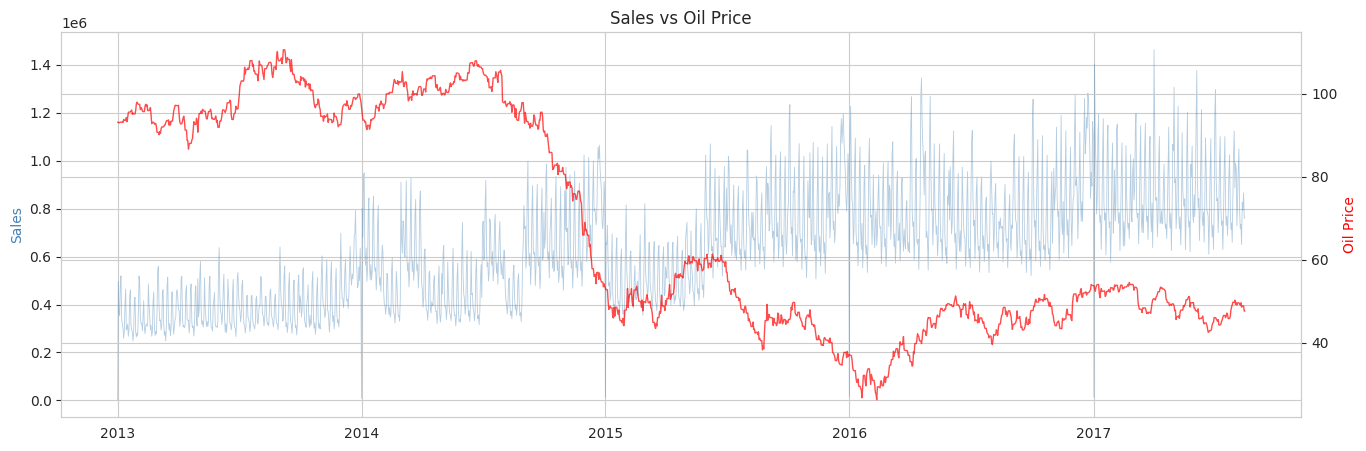

Correlation: -0.6271


In [28]:
tmp = daily_sales.reset_index(); tmp.columns = ['date', 'sales']
tmp = tmp.merge(oil, on='date', how='left'); tmp['oil_price'] = tmp['oil_price'].ffill()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(tmp['date'], tmp['sales'], color='steelblue', alpha=0.4, lw=0.6)
ax2.plot(tmp['date'], tmp['oil_price'], color='red', alpha=0.7, lw=1)
ax1.set_ylabel('Sales', color='steelblue'); ax2.set_ylabel('Oil Price', color='red')
plt.title('Sales vs Oil Price'); plt.show()

print(f"Correlation: {tmp[['sales','oil_price']].corr().iloc[0,1]:.4f}")
del tmp

### Product Families, Store Types & Promotion Effect

**What:** Which product families sell most? How do store types differ? How big is the promotion effect?
**Why:** These patterns guide feature importance and model expectations.

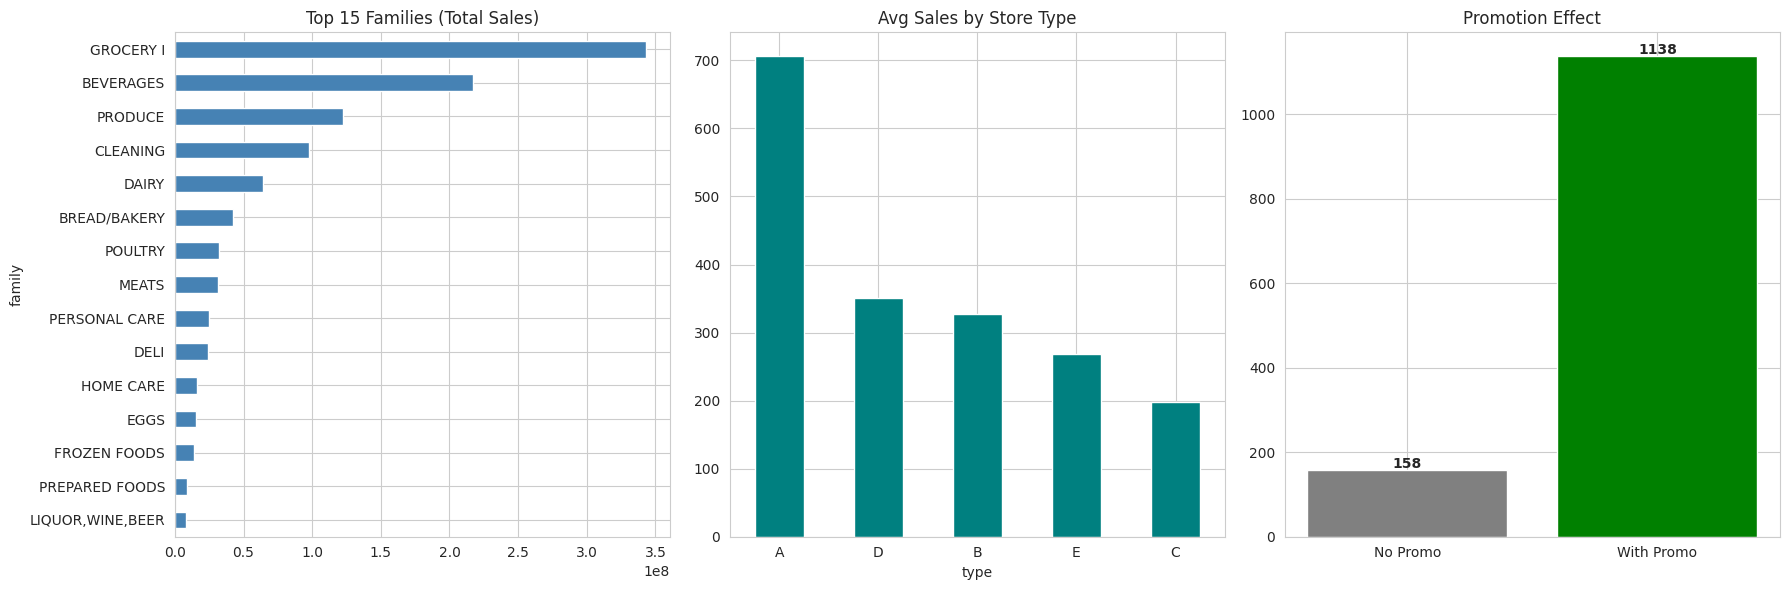

Promotion lift: 619%


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top families
fam = train.groupby('family')['sales'].sum().sort_values(ascending=False).head(15)
fam.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Families (Total Sales)'); axes[0].invert_yaxis()

# Store types
ts = train.merge(stores, on='store_nbr').groupby('type')['sales'].mean().sort_values(ascending=False)
ts.plot(kind='bar', ax=axes[1], color='teal', rot=0)
axes[1].set_title('Avg Sales by Store Type')

# Promotion effect
promo = train.groupby(train['onpromotion'] > 0)['sales'].mean()
axes[2].bar(['No Promo', 'With Promo'], promo.values, color=['gray', 'green'])
for i, v in enumerate(promo.values):
    axes[2].text(i, v+5, f'{v:.0f}', ha='center', fontweight='bold')
axes[2].set_title('Promotion Effect')

plt.tight_layout(); plt.show()
print(f"Promotion lift: {(promo[True]/promo[False]-1)*100:.0f}%")

### Year-over-Year Growth

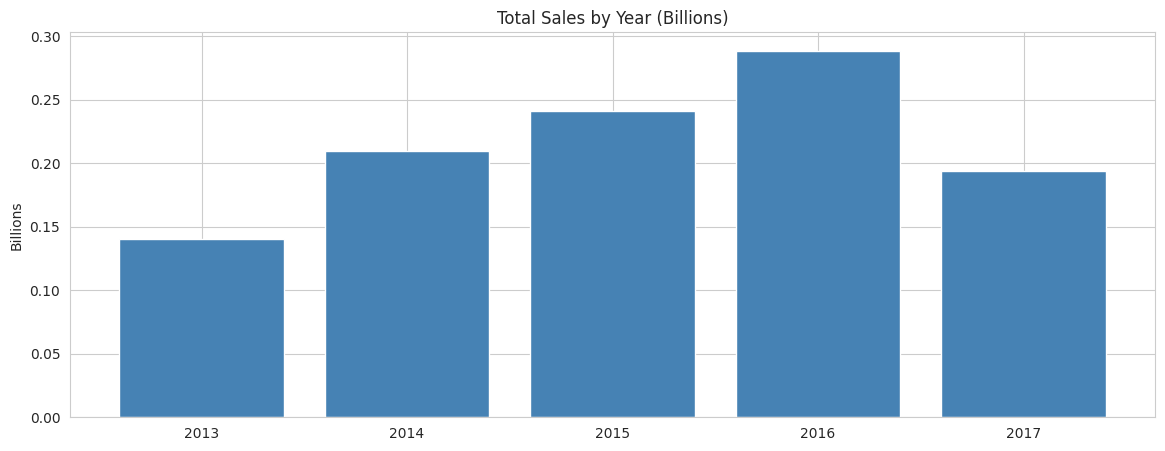

  2013->2014: +49.2%
  2014->2015: +15.0%
  2015->2016: +19.8%
  2016->2017: -32.7%
  (2017 is partial — only up to August)


In [30]:
train['year'] = train['date'].dt.year
yr = train.groupby('year')['sales'].sum() / 1e9
plt.bar(yr.index, yr.values, color='steelblue', edgecolor='white')
plt.title('Total Sales by Year (Billions)'); plt.ylabel('Billions'); plt.show()

for i in range(1, len(yr)):
    print(f"  {yr.index[i-1]}->{yr.index[i]}: {(yr.iloc[i]/yr.iloc[i-1]-1)*100:+.1f}%")
print("  (2017 is partial — only up to August)")

## Feature Engineering

**Technique:** Build predictive features from all available data sources.

| Category | Features | Why |
|----------|----------|-----|
| Calendar | year, month, day, dayofweek, weekofyear, weekend | Captures seasonal cycles |
| Payday | is_payday, near_payday | Public sector wage effect |
| Earthquake | is_earthquake_period | Anomalous period needs special handling |
| Store | city, state, type, cluster | Different stores have different sales patterns |
| Holidays | national_holiday, transfer_holiday, event | Holidays affect shopping behavior |
| Oil | oil_price | Economic indicator for Ecuador |
| Lags | lag_1, lag_7, lag_14, lag_28 | Past sales predict future sales |
| Rolling | rolling_mean_7/14/28, rolling_std_7 | Smoothed trends and volatility |
| Transactions | avg_store_dow_txn | Historical store traffic patterns |

### Calendar & Domain Features

In [31]:
def add_date_features(df):
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    df['is_payday'] = ((df['day'] == 15) | (df['is_month_end'] == 1)).astype(int)
    df['near_payday'] = (((df['day'] >= 13) & (df['day'] <= 17)) | (df['day'] >= 28) | (df['day'] <= 2)).astype(int)
    eq_start, eq_end = pd.Timestamp('2016-04-16'), pd.Timestamp('2016-05-31')
    df['is_earthquake_period'] = ((df['date'] >= eq_start) & (df['date'] <= eq_end)).astype(int)
    return df

train = add_date_features(train)
test  = add_date_features(test)
print("Calendar features added.")

Calendar features added.


### Store Metadata

**Technique:** Label-encode categorical columns (city, state, type) so tree-based models can use them.

In [32]:
le_city, le_state, le_type = LabelEncoder(), LabelEncoder(), LabelEncoder()
stores['city_enc']  = le_city.fit_transform(stores['city'])
stores['state_enc'] = le_state.fit_transform(stores['state'])
stores['type_enc']  = le_type.fit_transform(stores['type'])

cols = ['store_nbr', 'city_enc', 'state_enc', 'type_enc', 'cluster']
train = train.merge(stores[cols], on='store_nbr', how='left')
test  = test.merge(stores[cols], on='store_nbr', how='left')
print("Store metadata merged.")

Store metadata merged.


### Holidays

**What we do:** Create separate binary flags for national holidays, transfer days, and events.
**Why separate?** A transferred holiday behaves like a normal day; the *Transfer* entry is the actual celebration.

In [33]:
nat = holidays[(holidays['locale']=='National') & (holidays['transferred']==False) & 
               (~holidays['type'].isin(['Work Day']))][['date']].drop_duplicates()
nat['is_national_holiday'] = 1

trans = holidays[holidays['type']=='Transfer'][['date']].drop_duplicates()
trans['is_transfer_holiday'] = 1

evts = holidays[holidays['type']=='Event'][['date']].drop_duplicates()
evts['is_event'] = 1

for df in [train, test]:
    pass
train = train.merge(nat, on='date', how='left').merge(trans, on='date', how='left').merge(evts, on='date', how='left')
test  = test.merge(nat, on='date', how='left').merge(trans, on='date', how='left').merge(evts, on='date', how='left')

for c in ['is_national_holiday', 'is_transfer_holiday', 'is_event']:
    train[c] = train[c].fillna(0).astype(int)
    test[c]  = test[c].fillna(0).astype(int)
print("Holiday features added.")

Holiday features added.


### Oil Prices & Family Encoding

In [34]:
train = train.merge(oil, on='date', how='left')
test  = test.merge(oil, on='date', how='left')
train['oil_price'] = train['oil_price'].ffill().bfill()
test['oil_price']  = test['oil_price'].ffill().bfill()

le_family = LabelEncoder()
train['family_enc'] = le_family.fit_transform(train['family'])
test['family_enc']  = le_family.transform(test['family'])
print(f"Oil merged. Family encoded ({train['family_enc'].nunique()} categories).")

Oil merged. Family encoded (33 categories).


### Lag & Rolling Features

**Technique:** Use `shift()` to create lagged sales values. Shift by at least 1 to avoid data leakage.

| Feature | What it captures |
|---------|-----------------|
| lag_1 | Yesterday's sales (short-term momentum) |
| lag_7 | Same day last week (weekly cycle) |
| lag_14 | Two weeks ago |
| lag_28 | Four weeks ago (monthly cycle) |
| rolling_mean_7/14/28 | Average sales over recent window (trend) |
| rolling_std_7 | Sales volatility (stability measure) |

In [35]:
train = train.sort_values(['store_nbr', 'family_enc', 'date']).reset_index(drop=True)

for lag in [1, 7, 14, 28]:
    train[f'lag_{lag}'] = train.groupby(['store_nbr', 'family_enc'])['sales'].shift(lag)

for w in [7, 14, 28]:
    train[f'rolling_mean_{w}'] = train.groupby(['store_nbr','family_enc'])['sales'].shift(1).rolling(w).mean()

train['rolling_std_7'] = train.groupby(['store_nbr','family_enc'])['sales'].shift(1).rolling(7).std()

before = len(train)
lag_cols = [f'lag_{l}' for l in [1,7,14,28]] + ['rolling_mean_7','rolling_mean_14','rolling_mean_28','rolling_std_7']
train = train.dropna(subset=lag_cols)
print(f"Lag/rolling features added. Dropped {before-len(train):,} NaN rows. Remaining: {len(train):,}")

Lag/rolling features added. Dropped 49,896 NaN rows. Remaining: 2,950,992


### Transaction History

**Technique:** Compute average transactions per store per day-of-week from historical data.
This acts as a proxy for store traffic on each weekday.

In [36]:
txn = transactions.copy()
txn['dayofweek'] = txn['date'].dt.dayofweek
avg_txn = txn.groupby(['store_nbr', 'dayofweek'])['transactions'].mean().reset_index()
avg_txn.rename(columns={'transactions': 'avg_store_dow_txn'}, inplace=True)

train = train.merge(avg_txn, on=['store_nbr','dayofweek'], how='left')
test  = test.merge(avg_txn, on=['store_nbr','dayofweek'], how='left')
train['avg_store_dow_txn'] = train['avg_store_dow_txn'].fillna(0)
test['avg_store_dow_txn']  = test['avg_store_dow_txn'].fillna(0)

print(f"Transaction features added. Final train: {train.shape} | Final test: {test.shape}")
del txn; gc.collect()

Transaction features added. Final train: (2950992, 35) | Final test: (28512, 26)


25287

## Modeling

### Approach
| Choice | Reason |
|--------|--------|
| **Log1p transform** on target | RMSLE metric = MSE on log-transformed values |
| **Time-based validation** | Correct for time series — never peek into the future |
| **3 models compared** | Random Forest (baseline), LightGBM (primary), XGBoost (alternative) |
| **3 intervals: 7, 15, 30 days** | Tests robustness at different horizons; test set = 15 days |

In [37]:
FEATURES = [
    'store_nbr', 'family_enc', 'onpromotion',
    'year', 'month', 'day', 'dayofweek', 'weekofyear',
    'is_weekend', 'is_payday', 'near_payday', 'is_month_start', 'is_month_end',
    'is_earthquake_period',
    'city_enc', 'state_enc', 'type_enc', 'cluster',
    'is_national_holiday', 'is_transfer_holiday', 'is_event',
    'oil_price',
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7',
    'avg_store_dow_txn',
]
print(f"Using {len(FEATURES)} features")

Using 31 features


### Model Comparison: 7-Day, 15-Day, 30-Day Validation

**What:** Train each model on data before the split, validate on the last N days.
**Why 3 intervals?** The test set is 15 days, but checking 7 and 30 days shows if the model
generalizes well at shorter and longer horizons too.

In [ ]:
results = []

for n_days in [7, 15, 30]:
    print(f"\n{'='*50}")
    print(f" Validation: Last {n_days} days")
    print(f"{'='*50}")
    
    split = train['date'].max() - pd.Timedelta(days=n_days)
    X_tr = train[train['date'] <= split][FEATURES]
    y_tr = np.log1p(train[train['date'] <= split]['sales'])
    X_vl = train[train['date'] > split][FEATURES]
    y_vl = train[train['date'] > split]['sales']
    
    print(f" Train: {len(X_tr):,} | Val: {len(X_vl):,}")
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
    rf.fit(X_tr, y_tr)
    rf_score = rmsle(y_vl, np.expm1(rf.predict(X_vl)))
    print(f" Random Forest RMSLE: {rf_score:.6f}")
    results.append({'days': n_days, 'model': 'RandomForest', 'rmsle': rf_score})
    
    # LightGBM
    lgbm = lgb.LGBMRegressor(n_estimators=1500, learning_rate=0.02, num_leaves=128,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
        reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1)
    lgbm.fit(X_tr, y_tr, eval_set=[(X_vl, np.log1p(y_vl))],
             callbacks=[lgb.early_stopping(50, verbose=False)])
    lgbm_score = rmsle(y_vl, np.expm1(lgbm.predict(X_vl)))
    print(f" LightGBM RMSLE:     {lgbm_score:.6f} (best iter: {lgbm.best_iteration_})")
    results.append({'days': n_days, 'model': 'LightGBM', 'rmsle': lgbm_score})
    
    # XGBoost
    xgb = XGBRegressor(n_estimators=1000, learning_rate=0.02, max_depth=8,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_tr, y_tr, eval_set=[(X_vl, np.log1p(y_vl))], verbose=False)
    xgb_score = rmsle(y_vl, np.expm1(xgb.predict(X_vl)))
    print(f" XGBoost RMSLE:      {xgb_score:.6f}")
    results.append({'days': n_days, 'model': 'XGBoost', 'rmsle': xgb_score})

del rf, xgb; gc.collect()

res = pd.DataFrame(results)
print(f"\n{'='*50}")
print(res.pivot(index='model', columns='days', values='rmsle').to_string())


 Validation: Last 7 days
 Train: 2,938,518 | Val: 12,474


### Results Visualization

In [ ]:
res = pd.DataFrame(results)
pivot = res.pivot(index='model', columns='days', values='rmsle')

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, rot=0, edgecolor='white')
ax.set_title('Model Comparison: RMSLE at 7 / 15 / 30-Day Intervals')
ax.set_ylabel('RMSLE (lower = better)')
ax.legend(title='Interval (days)')
for c in ax.containers:
    ax.bar_label(c, fmt='%.4f', fontsize=8, padding=2)
plt.tight_layout(); plt.show()

best = res.loc[res['rmsle'].idxmin()]
print(f"Best: {best['model']} at {int(best['days'])}-day interval | RMSLE = {best['rmsle']:.6f}")

### Feature Importance

**What:** Which features contribute most to predictions?
**Why:** Confirms our feature engineering worked and helps with potential feature pruning.

In [ ]:
split = train['date'].max() - pd.Timedelta(days=15)
lgbm_imp = lgb.LGBMRegressor(n_estimators=1500, learning_rate=0.02, num_leaves=128,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1)
lgbm_imp.fit(train[train['date']<=split][FEATURES], np.log1p(train[train['date']<=split]['sales']))

imp = pd.DataFrame({'feature': FEATURES, 'importance': lgbm_imp.feature_importances_}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(data=imp, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance (LightGBM)'); plt.tight_layout(); plt.show()

print("Top 10:")
for _, r in imp.head(10).iterrows():
    print(f"  {r['feature']:25s} {r['importance']:>6.0f}")

## Submission Generation

**Technique: Recursive Day-by-Day Forecasting**

Since the test set spans 15 days into the future, we can't just compute lag features from training data alone
(day 2 needs day 1's prediction as lag_1, day 8 needs day 1's prediction as lag_7, etc.).

**How it works:**
1. Predict day 1 using training data lags
2. Add day 1 predictions to our history
3. Predict day 2 using updated history (including day 1 predictions)
4. Repeat for all 15 days

In [ ]:
model_final = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=128,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1)
model_final.fit(train[FEATURES], np.log1p(train['sales']))
print(f"Final model trained on {len(train):,} rows.")

In [ ]:
history = train[['store_nbr', 'family_enc', 'date', 'sales']].copy()
test_dates = sorted(test['date'].unique())
all_preds = []

for i, d in enumerate(test_dates):
    dt = test[test['date'] == d].copy()
    
    for lag in [1, 7, 14, 28]:
        ld = history[history['date'] == d - pd.Timedelta(days=lag)][['store_nbr','family_enc','sales']]
        dt = dt.merge(ld.rename(columns={'sales': f'lag_{lag}'}), on=['store_nbr','family_enc'], how='left')
    
    for w in [7, 14, 28]:
        wd = history[(history['date'] >= d-pd.Timedelta(days=w)) & (history['date'] < d)]
        rm = wd.groupby(['store_nbr','family_enc'])['sales'].mean().reset_index()
        dt = dt.merge(rm.rename(columns={'sales': f'rolling_mean_{w}'}), on=['store_nbr','family_enc'], how='left')
    
    wd7 = history[(history['date'] >= d-pd.Timedelta(days=7)) & (history['date'] < d)]
    rs = wd7.groupby(['store_nbr','family_enc'])['sales'].std().reset_index()
    dt = dt.merge(rs.rename(columns={'sales': 'rolling_std_7'}), on=['store_nbr','family_enc'], how='left')
    
    for c in FEATURES:
        if c in dt.columns:
            dt[c] = dt[c].fillna(0)
    
    preds = np.clip(np.expm1(model_final.predict(dt[FEATURES])), 0, None)
    dt['sales'] = preds
    all_preds.append(dt[['id', 'sales', 'store_nbr', 'family_enc', 'date']])
    history = pd.concat([history, dt[['store_nbr','family_enc','date','sales']]], ignore_index=True)
    
    print(f"Day {i+1:2d}/15: {d.date()} | mean={preds.mean():.1f}")

test_preds = pd.concat(all_preds, ignore_index=True)
print(f"\nTotal predictions: {len(test_preds):,}")

In [ ]:
submission = test_preds[['id', 'sales']].sort_values('id').reset_index(drop=True)

print(f"Shape: {submission.shape} (expected: {sample_sub.shape})")
print(f"Negative: {(submission['sales']<0).sum()} | Zero: {(submission['sales']==0).sum()}")
print(f"Mean: {submission['sales'].mean():.1f} | Max: {submission['sales'].max():.1f}")

submission.to_csv('submission.csv', index=False)
print("\nSaved: submission.csv")
submission.head(10)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(submission['sales'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Predicted Sales Distribution')
axes[1].hist(np.log1p(submission['sales']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('log1p(Predicted Sales) Distribution')
plt.tight_layout(); plt.show()

## Summary

| What we did | Technique used | Why |
|-------------|---------------|-----|
| Loaded all 6 files | pandas read_csv | Use all available information |
| 10 EDA analyses | matplotlib, seaborn | Understand data patterns |
| 30+ features | Calendar, lags, rolling stats, oil, stores, holidays, transactions | Give models rich signals |
| Log1p target | np.log1p / np.expm1 | Matches RMSLE metric |
| Time-based split | Last N days | Correct for time series |
| 3 validation intervals | 7, 15, 30 days | Test robustness |
| 3 models | Random Forest, LightGBM, XGBoost | Compare approaches |
| Recursive forecasting | Day-by-day with updated history | Proper multi-step prediction |

**Possible next steps:** Ensemble models, per-family models, Optuna hyperparameter tuning, Prophet residuals as features.